In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:

pima=pd.read_csv("Australian_Rainfall.csv")

In [ ]:
pima.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,17.9,35.2,0.0,12.0,12.3,SSW,48,ENE,SW,6,20,20,13,1006.3,1004.4,2,5,26.6,33.4,0
1,18.4,28.9,0.0,14.8,13.0,S,37,SSE,SSE,19,19,30,8,1012.9,1012.1,1,1,20.3,27.0,0
2,19.4,37.6,0.0,10.8,10.6,NNE,46,NNE,NNW,30,15,42,22,1012.3,1009.2,1,6,28.7,34.9,0
3,21.9,38.4,0.0,11.4,12.2,WNW,31,WNW,WSW,6,6,37,22,1012.7,1009.1,1,5,29.1,35.6,0
4,24.2,41.0,0.0,11.2,8.4,WNW,35,NW,WNW,17,13,19,15,1010.7,1007.4,1,6,33.6,37.6,0


In [ ]:
# Load the dataset

print(f'Shape: {pima.shape}')

Shape: (230, 20)


In [ ]:
#Check for missing values
print("\nMissing values before cleaning:")
print(pima.isnull().sum())
print(f"\nTotal missing values: {pima.isnull().sum().sum()}")





Missing values before cleaning:
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainTomorrow     0
dtype: int64

Total missing values: 0


In [ ]:
print(pima.select_dtypes(include=['object']).columns)


Index(['WindGustDir', 'WindDir9am', 'WindDir3pm'], dtype='object')


In [ ]:
le=LabelEncoder()
pima_encoded=pima.copy()
#store mappings
label_mappings={}

for col in pima.select_dtypes(include=['object']).columns:
    pima_encoded[col]=le.fit_transform(pima_encoded[col].astype(str))
    label_mappings[col]=dict(zip(le.classes_, le.transform(le.classes_)))

In [ ]:
for col, mapping in label_mappings.items():
    print(f"\nLabel Mapping for {col}:")
    print(mapping)


Label Mapping for WindGustDir:
{'E': np.int64(0), 'ENE': np.int64(1), 'ESE': np.int64(2), 'N': np.int64(3), 'NE': np.int64(4), 'NNE': np.int64(5), 'NNW': np.int64(6), 'NW': np.int64(7), 'S': np.int64(8), 'SE': np.int64(9), 'SSE': np.int64(10), 'SSW': np.int64(11), 'SW': np.int64(12), 'W': np.int64(13), 'WNW': np.int64(14), 'WSW': np.int64(15)}

Label Mapping for WindDir9am:
{'E': np.int64(0), 'ENE': np.int64(1), 'ESE': np.int64(2), 'N': np.int64(3), 'NE': np.int64(4), 'NNE': np.int64(5), 'NNW': np.int64(6), 'NW': np.int64(7), 'S': np.int64(8), 'SE': np.int64(9), 'SSE': np.int64(10), 'SSW': np.int64(11), 'SW': np.int64(12), 'W': np.int64(13), 'WNW': np.int64(14), 'WSW': np.int64(15)}

Label Mapping for WindDir3pm:
{'E': np.int64(0), 'ENE': np.int64(1), 'ESE': np.int64(2), 'N': np.int64(3), 'NE': np.int64(4), 'NNE': np.int64(5), 'NNW': np.int64(6), 'NW': np.int64(7), 'S': np.int64(8), 'SE': np.int64(9), 'SSE': np.int64(10), 'SSW': np.int64(11), 'SW': np.int64(12), 'W': np.int64(13), 'WN

In [ ]:
print(pima_encoded.head())
print(pima_encoded.dtypes)

   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustDir  \
0     17.9     35.2       0.0         12.0      12.3           11   
1     18.4     28.9       0.0         14.8      13.0            8   
2     19.4     37.6       0.0         10.8      10.6            5   
3     21.9     38.4       0.0         11.4      12.2           14   
4     24.2     41.0       0.0         11.2       8.4           14   

   WindGustSpeed  WindDir9am  WindDir3pm  WindSpeed9am  WindSpeed3pm  \
0             48           1          12             6            20   
1             37          10          10            19            19   
2             46           5           6            30            15   
3             31          14          15             6             6   
4             35           7          14            17            13   

   Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  \
0           20           13       1006.3       1004.4         2         5  

In [ ]:
print(pima_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        230 non-null    float64
 1   MaxTemp        230 non-null    float64
 2   Rainfall       230 non-null    float64
 3   Evaporation    230 non-null    float64
 4   Sunshine       230 non-null    float64
 5   WindGustDir    230 non-null    int64  
 6   WindGustSpeed  230 non-null    int64  
 7   WindDir9am     230 non-null    int64  
 8   WindDir3pm     230 non-null    int64  
 9   WindSpeed9am   230 non-null    int64  
 10  WindSpeed3pm   230 non-null    int64  
 11  Humidity9am    230 non-null    int64  
 12  Humidity3pm    230 non-null    int64  
 13  Pressure9am    230 non-null    float64
 14  Pressure3pm    230 non-null    float64
 15  Cloud9am       230 non-null    int64  
 16  Cloud3pm       230 non-null    int64  
 17  Temp9am        230 non-null    float64
 18  Temp3pm   

In [ ]:
pima.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
count,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000
mean,12.690000,24.527391,1.127826,6.150435,8.407391,36.752174,13.747826,14.500000,56.391304,36.356522,1017.288261,1014.659565,3.313043,4.047826,17.129130,23.231739,0.121739
std,6.659743,8.124349,4.338777,4.267249,3.623997,11.573361,6.708977,6.679663,20.342566,20.897417,5.520117,5.420886,2.866354,2.408567,6.525501,7.811418,0.327697
min,0.200000,11.400000,0.000000,0.000000,0.000000,15.000000,2.000000,2.000000,19.000000,5.000000,1004.800000,1003.300000,0.000000,1.000000,5.600000,9.600000,0.000000
25%,7.200000,17.725000,0.000000,2.600000,6.300000,28.000000,7.000000,9.000000,42.000000,21.250000,1013.125000,1010.700000,1.000000,2.000000,11.750000,16.925000,0.000000
50%,11.250000,22.550000,0.000000,4.800000,9.700000,35.000000,13.000000,13.000000,53.000000,31.000000,1017.200000,1014.100000,2.000000,4.000000,15.800000,21.700000,0.000000
75%,17.900000,31.375000,0.000000,8.950000,10.975000,44.000000,19.000000,19.000000,72.750000,47.750000,1021.300000,1018.875000,6.750000,6.000000,21.900000,29.950000,0.000000
max,27.600000,42.000000,38.800000,17.400000,13.600000,69.000000,35.000000,37.000000,99.000000,97.000000,1029.700000,1027.000000,8.000000,8.000000,33.600000,40.400000,1.000000


In [ ]:
#The 'RainToday' column already exists in the DataFrame and is in the correct integer format.
# We will use this column directly as a feature, avoiding any re-processing that could lead to data loss.

# Define feature_cols using the existing 'RainToday_Binary' column
feature_cols = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
    'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am',
    'Cloud3pm', 'Temp9am', 'Temp3pm'] # Use the existing binary column




# Create feature matrix X and target vector y
X = pima[feature_cols].copy()
y = pima['RainTomorrow'].copy()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nRainTomorrow distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True)}")


Features shape: (230, 16)
Target shape: (230,)

RainTomorrow distribution:
RainTomorrow
0    202
1     28
Name: count, dtype: int64

Class balance: RainTomorrow
0    0.878261
1    0.121739
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

# 2. Standardize features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Create and train model
logreg = LogisticRegression(random_state=16, max_iter=1000)
logreg.fit(X_train_scaled, y_train) # Train on scaled data

# 4. Make predictions
y_pred = logreg.predict(X_test_scaled) # Predict on scaled data

Training set size: 184
Test set size: 46


In [ ]:
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[40,  0],
       [ 1,  5]])

In [ ]:
from sklearn.metrics import classification_report
target_names = ['No RainTomorrow', 'RainTommorow']
print(classification_report(y_test, y_pred, target_names=target_names))

                 precision    recall  f1-score   support

No RainTomorrow       0.98      1.00      0.99        40
   RainTommorow       1.00      0.83      0.91         6

       accuracy                           0.98        46
      macro avg       0.99      0.92      0.95        46
   weighted avg       0.98      0.98      0.98        46



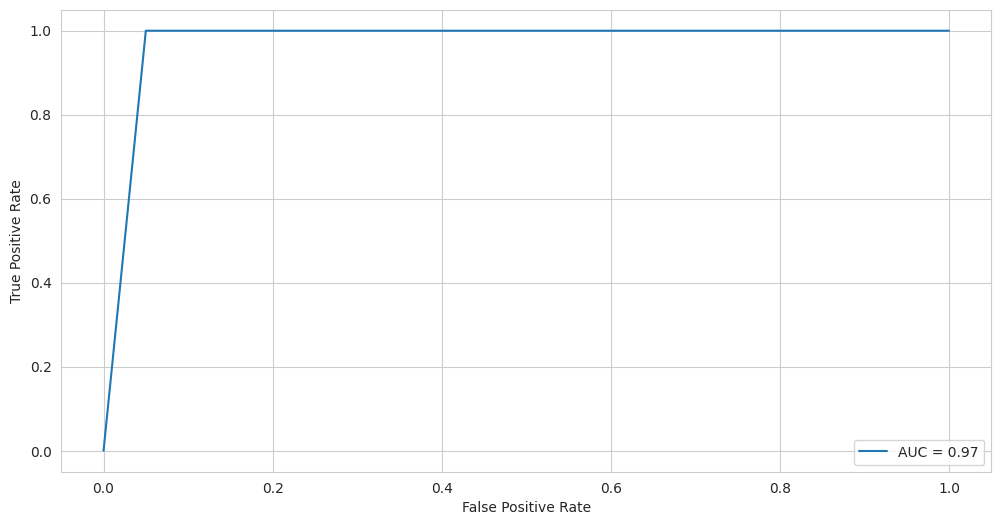

In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt
y_pred_proba = logreg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


# The previous dropna was not needed as there are no missing values and the column name was incorrect.
# If there were missing values, it should be pima = pima.dropna(subset=['RainTomorrow'])

X = pima[[    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
    'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am',
    'Cloud3pm', 'Temp9am', 'Temp3pm']]
y = pima['RainTomorrow'] # Corrected column name to RainTomorrow

# These lines were incorrect as MinTemp and MaxTemp are numerical and should not be mapped or filled this way.
# X['MinTemp'] = X['MinTemp'].map({'No TomorrowRain': 0, 'Tomorrowrain': 1})
# X['MaxTemp'] = X['MaxTemp'].fillna(X['feature_cols'].median())

# Ensure X has the correct columns and no unintended modifications

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

sample = X_test.iloc[0:1]
prediction = rf_classifier.predict(sample)

sample_dict = sample.iloc[0].to_dict()
print(f"\nSample Max Min temp: {sample_dict}")
print(f"Predicted rainfall: {'TommorowRain' if prediction[0] == 1 else ' No TomorrowRain'}")

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94        40
           1       1.00      0.17      0.29         6

    accuracy                           0.89        46
   macro avg       0.94      0.58      0.61        46
weighted avg       0.90      0.89      0.86        46


Sample Max Min temp: {'MinTemp': 11.2, 'MaxTemp': 24.1, 'Rainfall': 0.0, 'Evaporation': 3.8, 'Sunshine': 11.7, 'WindGustSpeed': 33.0, 'WindSpeed9am': 13.0, 'WindSpeed3pm': 15.0, 'Humidity9am': 54.0, 'Humidity3pm': 28.0, 'Pressure9am': 1020.3, 'Pressure3pm': 1018.6, 'Cloud9am': 1.0, 'Cloud3pm': 3.0, 'Temp9am': 16.2, 'Temp3pm': 21.9}
Predicted rainfall:  No TomorrowRain


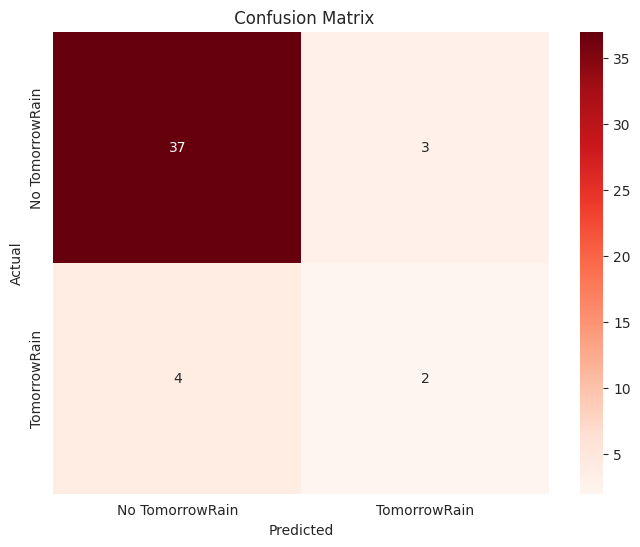

In [ ]:
#confusion matrix for random forest

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['No TomorrowRain', 'TomorrowRain']
            , yticklabels=['No TomorrowRain', 'TomorrowRain'])
plt.title(' Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

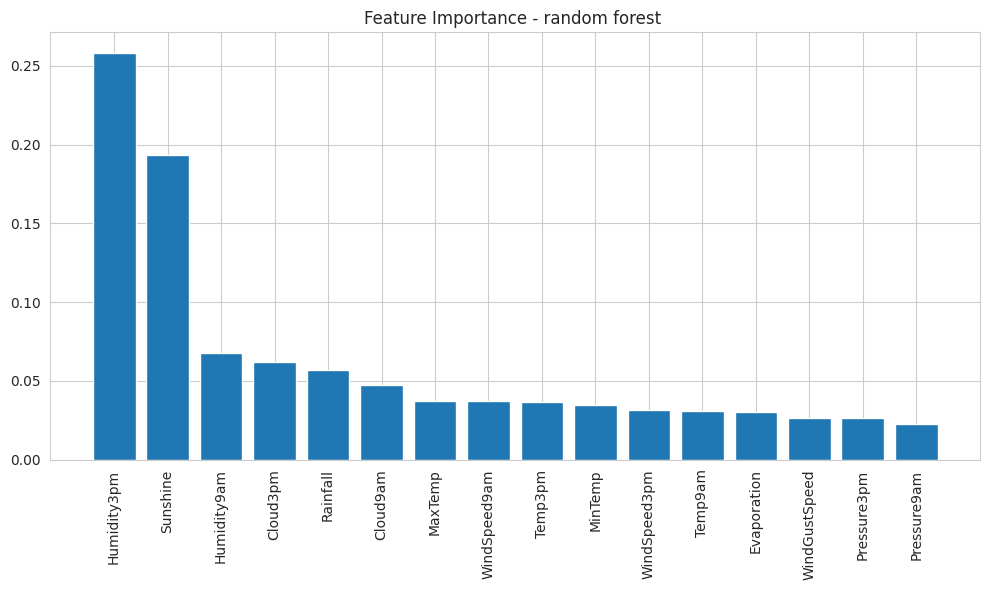

In [ ]:
importances = rf_classifier.feature_importances_

indices = np.argsort(importances)[::-1]


plt.figure(figsize=(10, 6))
plt.title("Feature Importance - random forest ")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()




In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn import metrics # Re-import metrics module to ensure it's not shadowed

# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8478260869565217


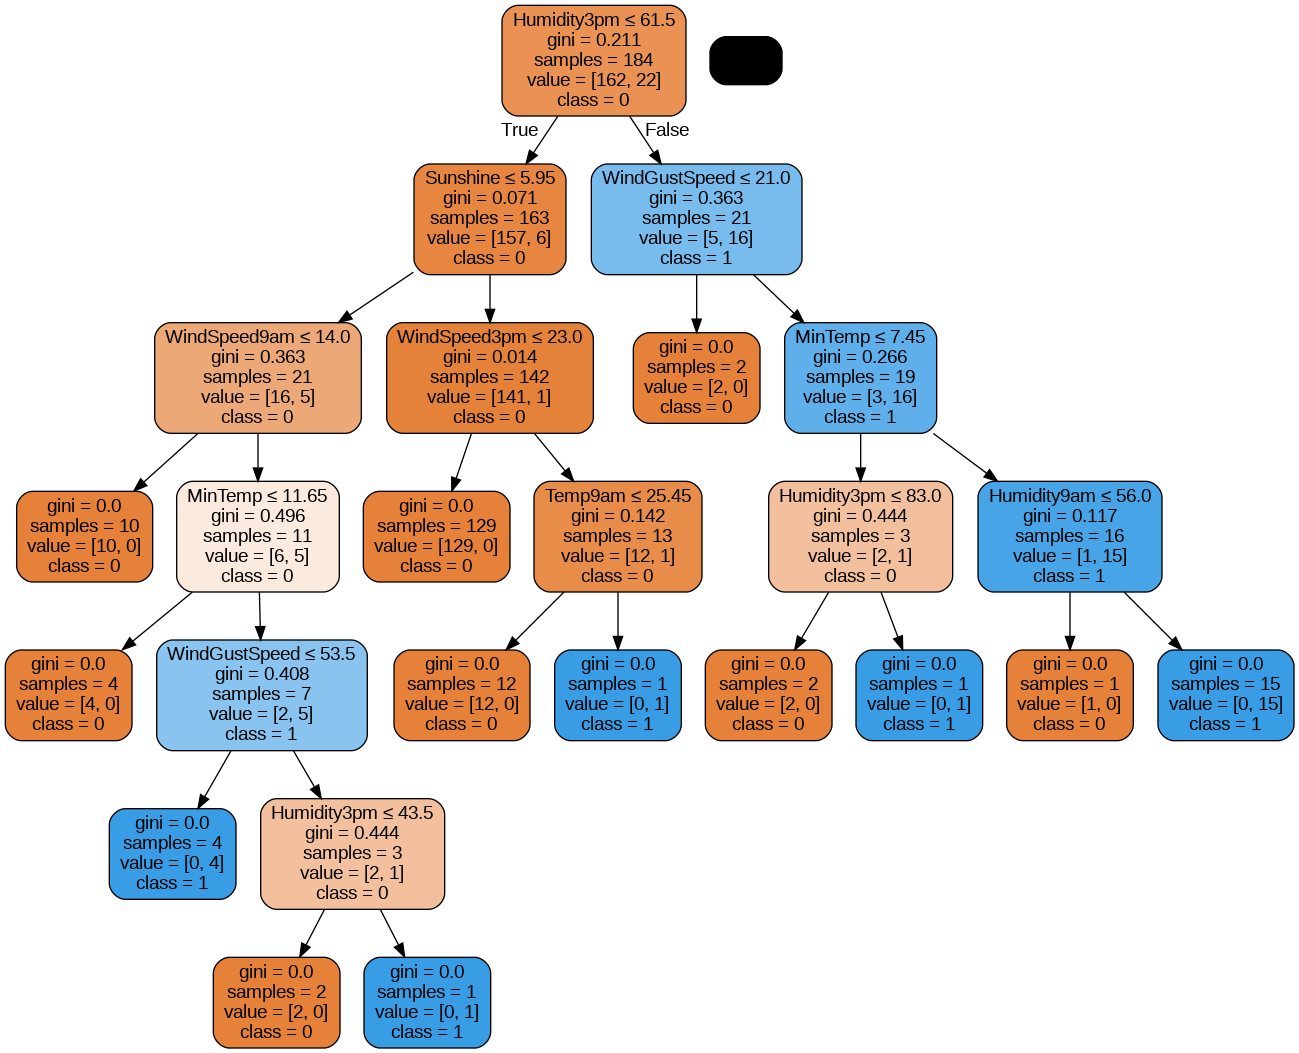

In [ ]:
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,feature_names = feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('Australian_Rainfall_gini.png')
Image(graph.create_png())

In [ ]:
# Train Decision Tree (using unscaled data as trees don't require scaling)
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=5)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation
print('\nDecision Tree Results:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dt):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_dt):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_dt):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['No TomorrowRain', 'TomorrowRain']))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))

# Cross-validation
cv_scores_dt = cross_val_score(dt_model, X_train, y_train, cv=5)
print(f'\nCross-Validation Scores: {cv_scores_dt}')
print(f'Mean CV Score: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std() * 2:.4f})')


Decision Tree Results:
Accuracy: 0.8261
Precision: 0.2500
Recall: 0.1667
F1-Score: 0.2000

Classification Report:
                 precision    recall  f1-score   support

No TomorrowRain       0.88      0.93      0.90        40
   TomorrowRain       0.25      0.17      0.20         6

       accuracy                           0.83        46
      macro avg       0.57      0.55      0.55        46
   weighted avg       0.80      0.83      0.81        46


Confusion Matrix:
[[37  3]
 [ 5  1]]

Cross-Validation Scores: [0.89189189 0.86486486 0.83783784 0.83783784 0.83333333]
Mean CV Score: 0.8532 (+/- 0.0447)


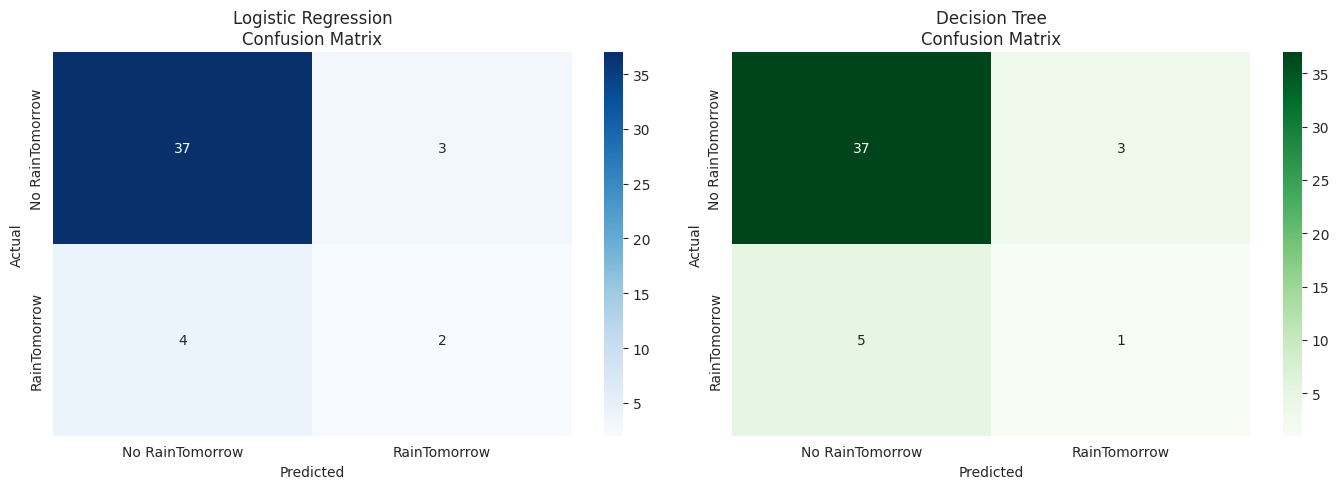

In [ ]:
# 1. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No RainTomorrow', 'RainTomorrow'])
axes[0].set_yticklabels(['No RainTomorrow', 'RainTomorrow'])

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No RainTomorrow', 'RainTomorrow'])
axes[1].set_yticklabels(['No RainTomorrow', 'RainTomorrow'])

plt.tight_layout()
plt.show()

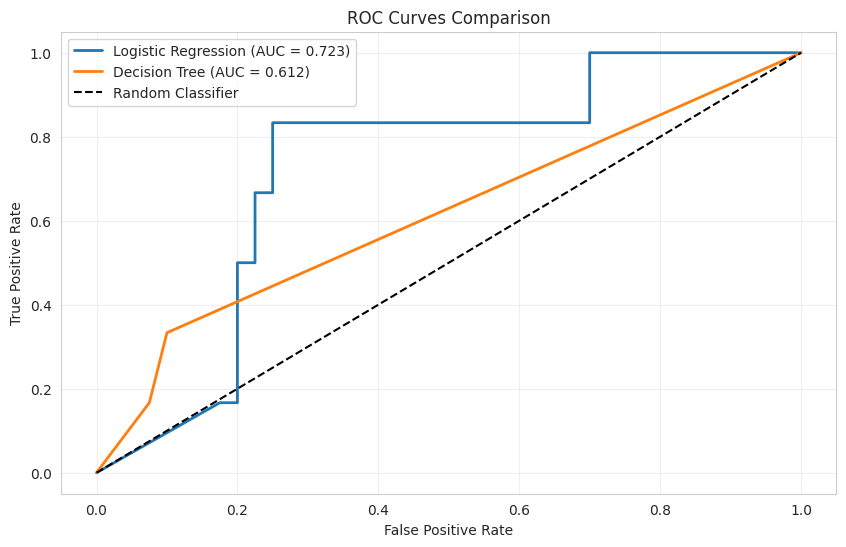

In [ ]:
# 2. ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Model Comparison Summary
              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.804348       0.20 0.166667  0.181818 0.712500
      Decision Tree  0.826087       0.25 0.166667  0.200000 0.612500
      Random Forest  0.847826       0.40 0.333333  0.363636 0.814583


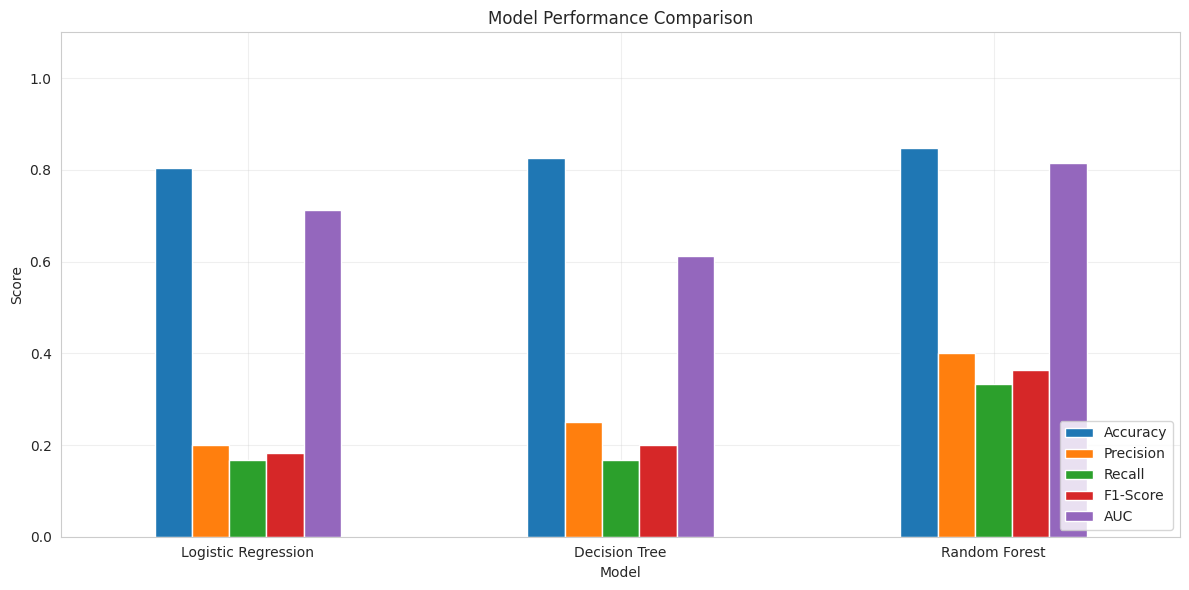


Analysis Complete!


In [ ]:
# Recalculate Logistic Regression predictions and AUC with scaled data
y_pred_lr = logreg.predict(X_test_scaled)
y_pred_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr_new = auc(fpr_lr, tpr_lr)

# Get Random Forest predictions and probabilities
# The y_pred variable from previous cell (05oOD_TBAx8D) is for Random Forest.
y_pred_rf = y_pred # Assuming y_pred from 05oOD_TBAx8D is the RF prediction
y_pred_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 4. Model Comparison
metrics = {
    'Model': ['Logistic Regression', 'Decision Tree','Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    'AUC': [roc_auc_lr_new, roc_auc_dt, roc_auc_rf]
}

comparison_df = pd.DataFrame(metrics)
print('\n' + '=' * 50)
print('Model Comparison Summary')
print('=' * 50)
print(comparison_df.to_string(index=False))

# Bar chart comparison
comparison_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n' + '=' * 50)
print('Analysis Complete!')
print('=' * 50)